In [1]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import gc
import os

In [3]:
# GPU Configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

GPU Memory Growth Enabled


In [4]:
# Clear any previous GPU memory allocations
tf.keras.backend.clear_session()
gc.collect()

# Set dataset path (Update this based on your dataset location)
dataset_path = os.path.expanduser(r"C:\Users\Asus\Downloads\archive (1)\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train")

  # Replace with actual path

# Image parameters
img_size = (224, 224)
batch_size = 32  # Reduce if you face memory issues

In [5]:
# Image settings
img_size = (224, 224)  # MobileNetV2 input size
batch_size = 32

In [6]:
# Load full dataset and then split manually into Train (70%), Val (20%), Test (10%)
full_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="categorical",
    image_size=img_size,
    shuffle=True,
    batch_size=batch_size
)

Found 70295 files belonging to 38 classes.


In [7]:
# Calculate dataset sizes
dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)
test_size = dataset_size - train_size - val_size

# Split dataset
train_dataset = full_dataset.take(train_size)
remaining = full_dataset.skip(train_size)
val_dataset = remaining.take(val_size)
test_dataset = remaining.skip(val_size)

# Prefetching for performance optimization
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [8]:
# Extract class names
class_names = full_dataset.class_names
num_classes = len(class_names)
print("Class Names:", class_names)

Class Names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomat

In [9]:
# Load MobileNetV2 (Pretrained)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Freeze base model layers

In [10]:
# Create model
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(full_dataset.class_names), activation="softmax")
])

In [11]:

# Compile model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [12]:
# Compute class weights
all_labels = []
for images, labels in full_dataset:
    all_labels.extend(np.argmax(labels.numpy(), axis=1))

class_weights_dict = dict(enumerate(class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)))
print("Class Weights:", class_weights_dict)

Class Weights: {0: 0.917593462823726, 1: 0.9309856170370566, 2: 1.0510616028708133, 3: 0.9212492136716293, 4: 1.0186500115928587, 5: 1.0991493886230728, 6: 1.013071424453796, 7: 1.1265946535034297, 8: 0.9700411227334198, 9: 0.9695327154363897, 10: 0.9950879080433737, 11: 0.9798031891168599, 12: 0.9634731359649122, 13: 1.074255761354606, 14: 1.0933028493218864, 15: 0.9203325477873789, 16: 1.006457247580322, 17: 1.0705257066276803, 18: 0.9669986518832365, 19: 0.9305173144127925, 20: 0.9540321923943432, 21: 0.9540321923943432, 22: 1.0141822483841183, 23: 1.038668400366441, 24: 0.9148706335571868, 25: 1.065592408440456, 26: 1.0427668664332759, 27: 1.0141822483841183, 28: 1.0868792133094192, 29: 0.9634731359649122, 30: 0.9993886661548523, 31: 0.9829268974774875, 32: 1.0600965163625395, 33: 1.0625321200761813, 34: 1.012516924495146, 35: 0.9433291285327035, 36: 1.0334460452807999, 37: 0.9604716620210964}


In [13]:
# Train model
epochs = 10
history = model.fit(train_dataset, validation_data=val_dataset, epochs=epochs)

Epoch 1/10
1537/1537 [==============================] - 284s 178ms/step - loss: 1.4691 - accuracy: 0.5714 - val_loss: 0.8970 - val_accuracy: 0.7313
Epoch 2/10
1537/1537 [==============================] - 327s 213ms/step - loss: 0.9238 - accuracy: 0.7130 - val_loss: 0.7060 - val_accuracy: 0.7840
Epoch 3/10
1537/1537 [==============================] - 179s 116ms/step - loss: 0.7987 - accuracy: 0.7479 - val_loss: 0.6196 - val_accuracy: 0.8074
Epoch 4/10
1537/1537 [==============================] - 179s 116ms/step - loss: 0.7203 - accuracy: 0.7724 - val_loss: 0.5850 - val_accuracy: 0.8154
Epoch 5/10
1537/1537 [==============================] - 178s 116ms/step - loss: 0.6701 - accuracy: 0.7868 - val_loss: 0.5655 - val_accuracy: 0.8195
Epoch 6/10
1537/1537 [==============================] - 178s 116ms/step - loss: 0.6342 - accuracy: 0.7966 - val_loss: 0.5464 - val_accuracy: 0.8268
Epoch 7/10
1537/1537 [==============================] - 179s 116ms/step - loss: 0.5969 - accuracy: 0.8068 - val_

In [14]:

# Evaluate model on test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

221/221 [==============================] - 57s 80ms/step - loss: 0.4741 - accuracy: 0.8494
Test Loss: 0.47410857677459717
Test Accuracy: 0.8493558168411255


In [15]:
# Save the model
model.save("plant_disease_model_70_20_10_corrected.h5")

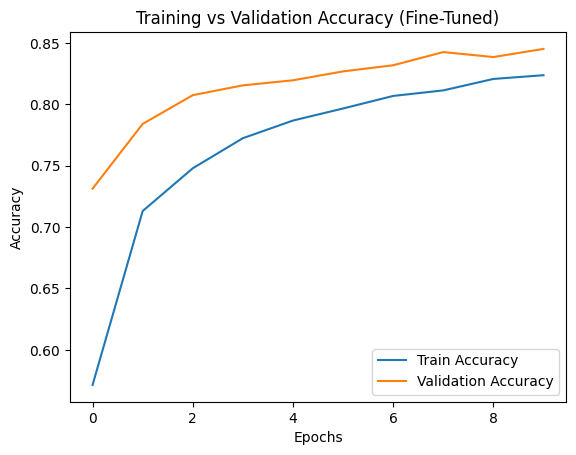

In [16]:
# Plot Training History
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (Fine-Tuned)")
plt.show()

In [17]:
# Compute predictions for the test dataset
y_true = []
y_pred = []
class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
               'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy',
               'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
               'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot',
               'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
               'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy',
               'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight',
               'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy',
               'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy',
               'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold',
               'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
               'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

for images, labels in test_dataset:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

1/1 [==============================] - 1s 619ms/step


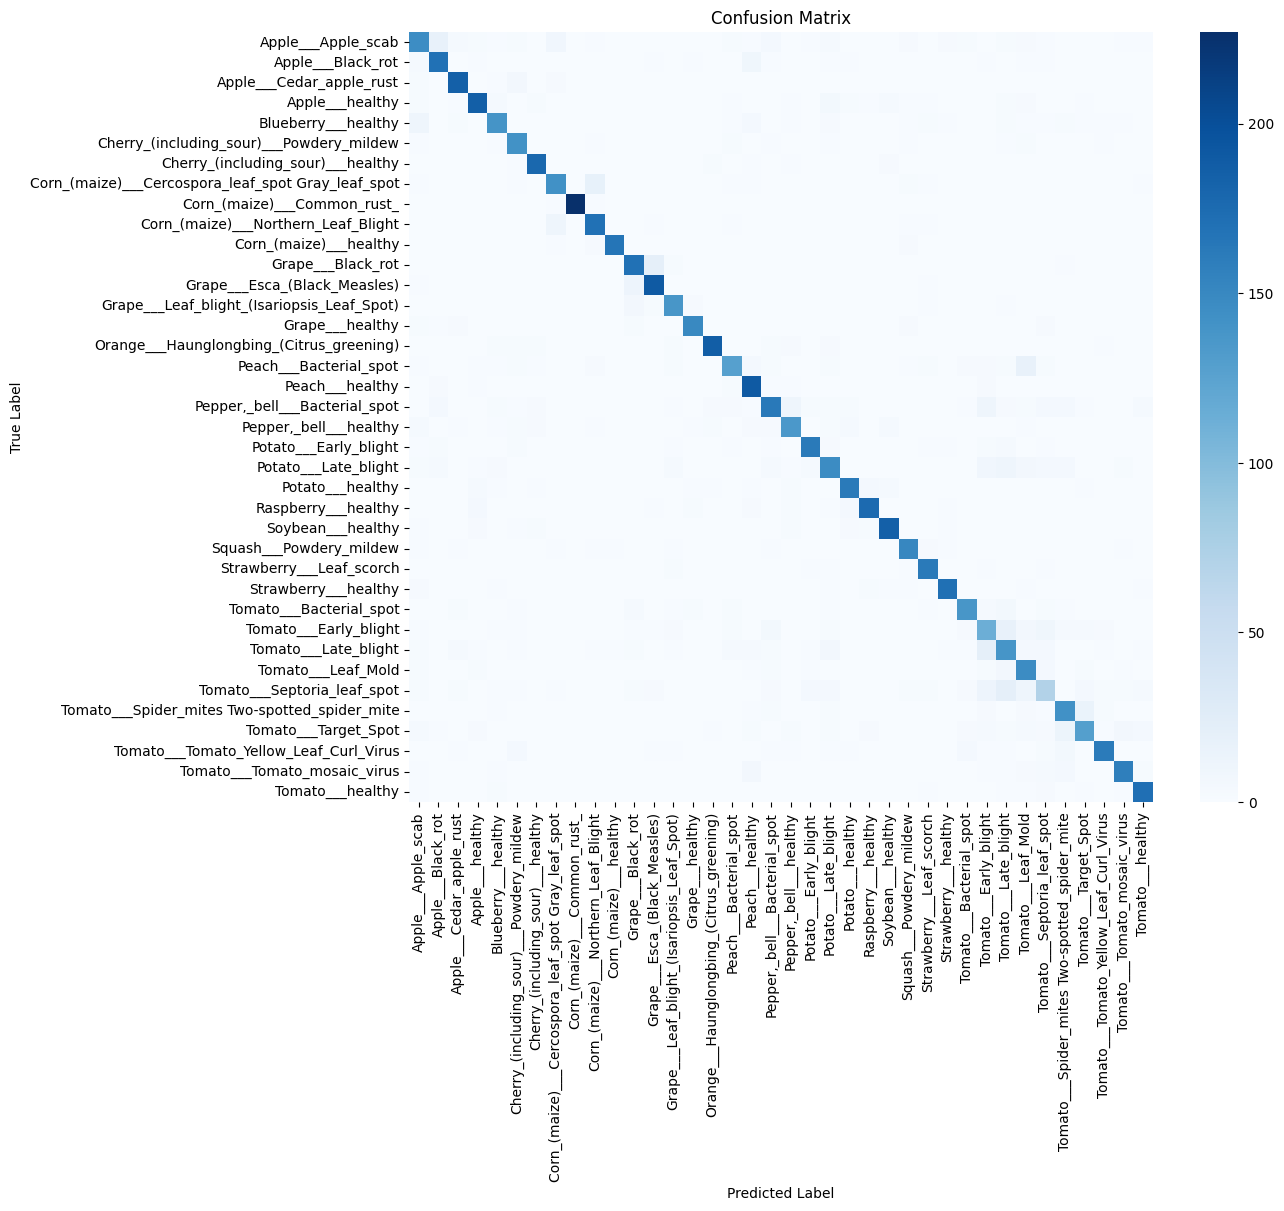

In [20]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [21]:
# Generate Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
                                                     precision    recall  f1-score   support

                                Apple___Apple_scab       0.74      0.70      0.72       210
                                 Apple___Black_rot       0.84      0.89      0.86       192
                          Apple___Cedar_apple_rust       0.90      0.93      0.92       198
                                   Apple___healthy       0.89      0.85      0.87       218
                               Blueberry___healthy       0.85      0.80      0.82       176
          Cherry_(including_sour)___Powdery_mildew       0.82      0.92      0.87       153
                 Cherry_(including_sour)___healthy       0.93      0.96      0.94       186
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.85      0.85       168
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       229
               Corn_(maize)___Northern_Leaf_Blight     

In [22]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import gc

In [23]:
# Clear GPU memory
import tensorflow.keras.backend as K
K.clear_session()
gc.collect()

31443

In [24]:
# Load your trained model
model = keras.models.load_model(r"D:\plant_disease_model_70_20_10_corrected.h5")

In [25]:

# Ensure only the last 20 layers are trainable
for layer in model.layers[:-20]:  
    layer.trainable = False 

In [26]:

# Compile the model again before continuing training
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),  
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [27]:

# Train for 20 more epochs
epochs_to_train = 20
history = model.fit(train_dataset, validation_data=val_dataset, epochs=epochs_to_train)

Epoch 1/20
1537/1537 [==============================] - 184s 118ms/step - loss: 0.4328 - accuracy: 0.8577 - val_loss: 0.4338 - val_accuracy: 0.8605
Epoch 2/20
1537/1537 [==============================] - 192s 125ms/step - loss: 0.3967 - accuracy: 0.8685 - val_loss: 0.4254 - val_accuracy: 0.8621
Epoch 3/20
1537/1537 [==============================] - 185s 120ms/step - loss: 0.3906 - accuracy: 0.8720 - val_loss: 0.4248 - val_accuracy: 0.8636
Epoch 4/20
1537/1537 [==============================] - 182s 118ms/step - loss: 0.3875 - accuracy: 0.8725 - val_loss: 0.4229 - val_accuracy: 0.8642
Epoch 5/20
1537/1537 [==============================] - 182s 118ms/step - loss: 0.3881 - accuracy: 0.8717 - val_loss: 0.4216 - val_accuracy: 0.8648
Epoch 6/20
1537/1537 [==============================] - 182s 119ms/step - loss: 0.3825 - accuracy: 0.8736 - val_loss: 0.4201 - val_accuracy: 0.8644
Epoch 7/20
1537/1537 [==============================] - 182s 118ms/step - loss: 0.3794 - accuracy: 0.8750 - val_

In [28]:
# Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"New Test Loss: {test_loss}")
print(f"New Test Accuracy: {test_accuracy}")

221/221 [==============================] - 57s 82ms/step - loss: 0.4045 - accuracy: 0.8743
New Test Loss: 0.4044917821884155
New Test Accuracy: 0.8742743730545044


In [29]:
# Save the newly trained model
model.save("plant_disease_model_corrected_30epochs.h5")

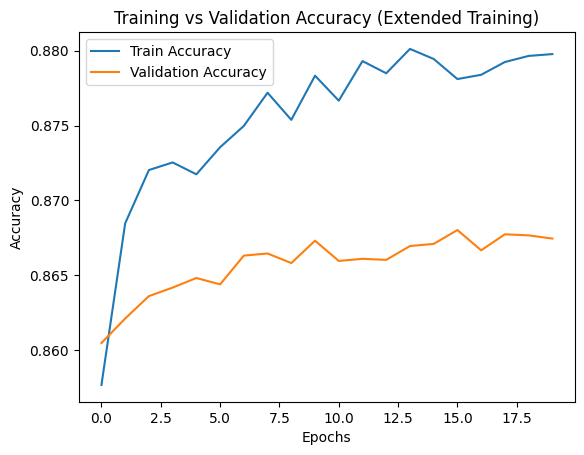

In [30]:
# Plot Training History
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (Extended Training)")
plt.show()

In [31]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import gc

In [32]:
# Clear GPU memory
import tensorflow.keras.backend as K
K.clear_session()
gc.collect()

13494

In [33]:
# Load your trained model
model = keras.models.load_model(r"D:\plant_disease_model_corrected_30epochs.h5")

In [34]:
# Ensure only the last 20 layers are trainable
for layer in model.layers[:-20]:  
    layer.trainable = False 

In [35]:
# Compile the model again before continuing training
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),  
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [36]:
# Train for 20 more epochs
epochs_to_train = 20
history = model.fit(train_dataset, validation_data=val_dataset, epochs=epochs_to_train)

Epoch 1/20
1537/1537 [==============================] - 189s 121ms/step - loss: 0.3610 - accuracy: 0.8811 - val_loss: 0.4094 - val_accuracy: 0.8687
Epoch 2/20
1537/1537 [==============================] - 185s 120ms/step - loss: 0.3639 - accuracy: 0.8796 - val_loss: 0.4079 - val_accuracy: 0.8680
Epoch 3/20
1537/1537 [==============================] - 185s 120ms/step - loss: 0.3639 - accuracy: 0.8800 - val_loss: 0.4079 - val_accuracy: 0.8683
Epoch 4/20
1537/1537 [==============================] - 186s 121ms/step - loss: 0.3573 - accuracy: 0.8819 - val_loss: 0.4091 - val_accuracy: 0.8675
Epoch 5/20
1537/1537 [==============================] - 178s 116ms/step - loss: 0.3586 - accuracy: 0.8812 - val_loss: 0.4083 - val_accuracy: 0.8674
Epoch 6/20
1537/1537 [==============================] - 177s 115ms/step - loss: 0.3607 - accuracy: 0.8816 - val_loss: 0.4090 - val_accuracy: 0.8678
Epoch 7/20
1537/1537 [==============================] - 179s 116ms/step - loss: 0.3577 - accuracy: 0.8821 - val_

In [37]:
# Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"New Test Loss: {test_loss}")
print(f"New Test Accuracy: {test_accuracy}")

221/221 [==============================] - 56s 77ms/step - loss: 0.4003 - accuracy: 0.8763
New Test Loss: 0.4002697169780731
New Test Accuracy: 0.87625652551651


In [38]:
# Save the newly trained model
model.save("plant_disease_model_corrected_50_epochs.h5")

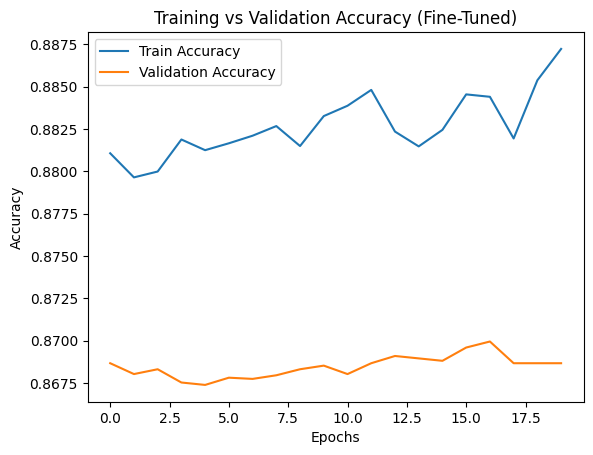

In [39]:
# Plot Training History
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (Fine-Tuned)")
plt.show()

In [40]:
# Compute predictions for the test dataset
y_true = []
y_pred = []
class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
               'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy',
               'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
               'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot',
               'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
               'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy',
               'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight',
               'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy',
               'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy',
               'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold',
               'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
               'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

for images, labels in test_dataset:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

1/1 [==============================] - 1s 574ms/step


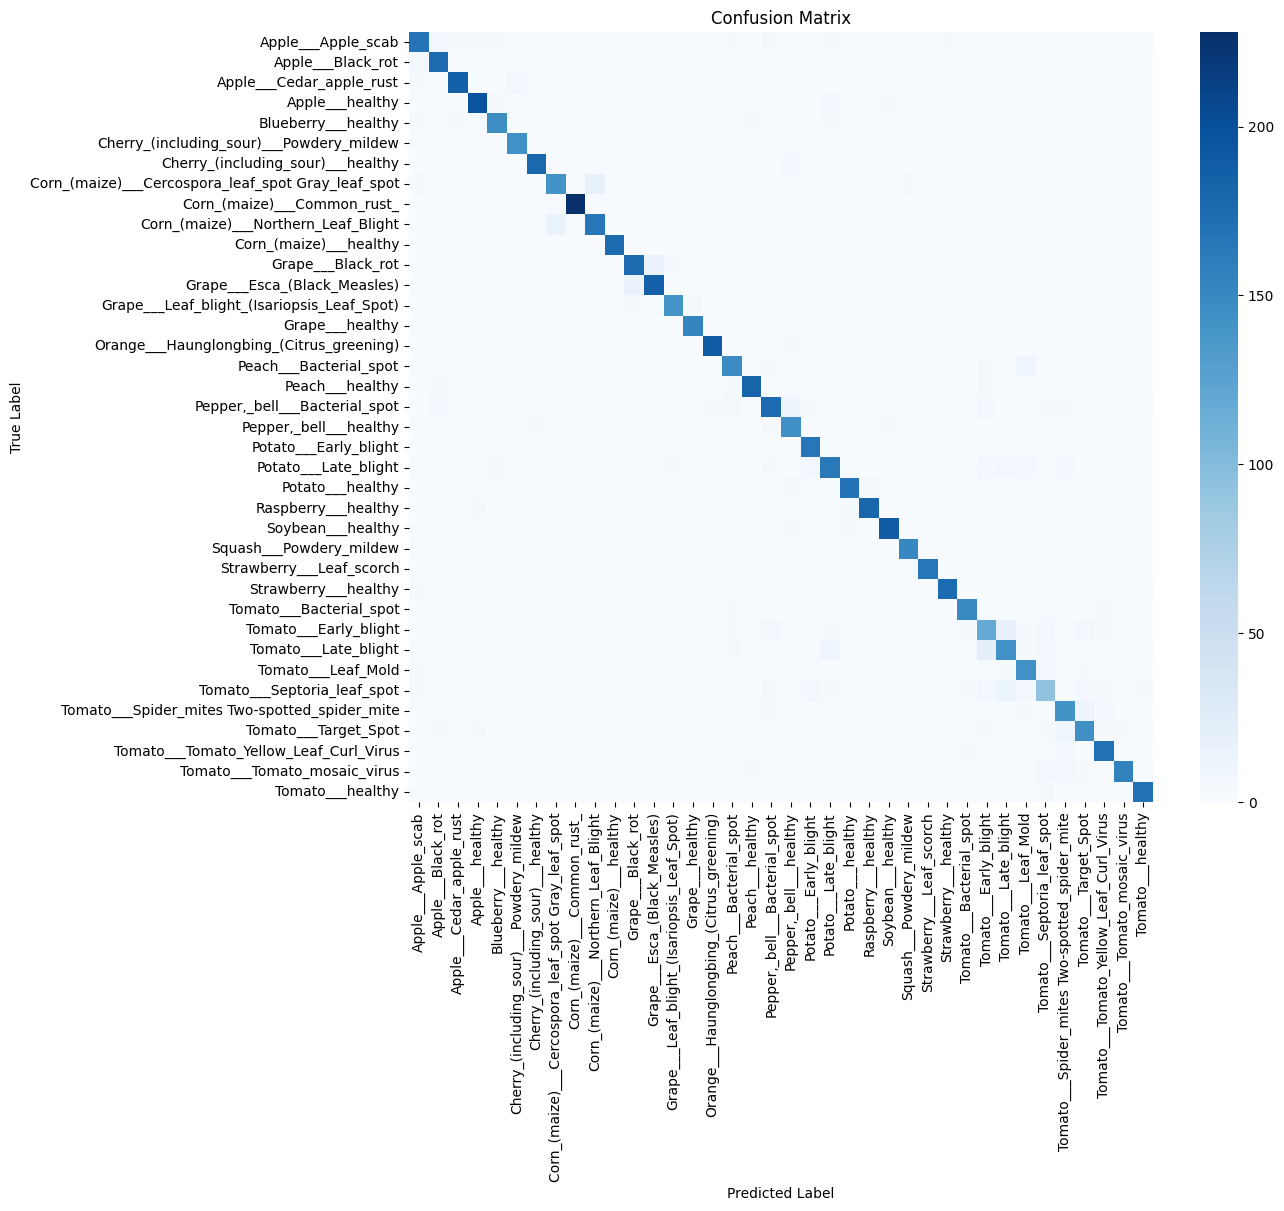

In [41]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [42]:
# Generate Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
                                                     precision    recall  f1-score   support

                                Apple___Apple_scab       0.81      0.80      0.80       211
                                 Apple___Black_rot       0.88      0.91      0.90       194
                          Apple___Cedar_apple_rust       0.94      0.93      0.94       198
                                   Apple___healthy       0.91      0.89      0.90       220
                               Blueberry___healthy       0.86      0.84      0.85       173
          Cherry_(including_sour)___Powdery_mildew       0.91      0.92      0.91       156
                 Cherry_(including_sour)___healthy       0.97      0.95      0.96       188
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.83      0.86       169
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       229
               Corn_(maize)___Northern_Leaf_Blight     